In [241]:
import numpy as np
import xarray as xr
# plottng
import cmocean as cmo
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.transforms import Bbox

import cartopy.crs as ccrs  # Projections list
import cartopy.feature as cfeature


import scipy
from scipy.stats import pearsonr
from amocatlas import read


In [242]:
ds = read.calafat2025()

Loading 1 Calafat et al. 2025 dataset(s):
  0. Bayesian_estimates_Atlantic_MHT.zip: No description available



In [243]:
# 3 month averages startomg mid february 2004
#ends mid august 2020
print(ds.coords)
# ### idx = 0 == lat 65
# print(ds.lat.isel(lat=0))
# coordinates: TIME, LATITUDE
# where to access the index use TIME and lat

Coordinates:
    LATITUDE    (lat) float64 96B 65.0 60.0 55.0 45.0 ... -5.0 -11.0 -25.0 -35.0
    LAT_BOUNDS  (lat, bound) float64 192B 67.5 62.5 62.5 ... -30.0 -30.0 -40.0
  * TIME        (TIME) datetime64[ns] 536B 2004-02-14T23:59:59.999996901 ... ...


In [244]:
lats = ds.LATITUDE.values
lat_labels = [f"{lat} °{'N' if lat > 0 else 'S'}" for lat in lats]
print(lat_labels)


['65.0 °N', '60.0 °N', '55.0 °N', '45.0 °N', '35.0 °N', '26.0 °N', '16.0 °N', '5.0 °N', '-5.0 °S', '-11.0 °S', '-25.0 °S', '-35.0 °S']


In [ ]:

def MHT_selection(ds, average=False, anomalies=False, one_band_sel=False, lat=None, statistics=False, printout=False):
    """
    Select and process MHT data
    get anomalies and statistics,
    select a specific latitude band
    
    """
    def _name(da, label):
        da.name = label
        return da
    
    lats = ds.LATITUDE.values
    MHT_prob = ds.MHT
    
    if printout:
        print("Initial MHT dims: ", MHT_prob.dims)
        nan_mask = np.isnan(MHT_prob).any(dim=["lat", "posterior_samples"])
        print("Timesteps with NaN: ", MHT_prob.TIME.where(nan_mask, drop=True).values)# Average over posterior samples or keep all
        
    MHT = MHT_prob.mean(dim="posterior_samples", skipna=True) if average else MHT_prob

    # Drop timesteps with any NaN
    MHT = MHT.dropna(dim="TIME", how="any")
    # get mean and std
    statistics_results = None
    if statistics:
        mht_mean = MHT.mean(dim="TIME", skipna=True)
        mht_std = MHT.std(dim="TIME", skipna=True)
        
        mht_mean = _name(mht_mean, "MHT mean")
        mht_std = _name(mht_std, "MHT std")
        statistics_results = {
            "mean": mht_mean,
            "std": mht_std
        }
        
    # Anomalies
    mht_anom = None
    if anomalies:
        mht_mean = MHT.mean(dim="TIME", skipna=True)
        mht_anom = MHT - mht_mean
        mht_anom = _name(mht_anom, "MHT anomalies")

    # Latitude selection (applied to anomalies if available, else raw MHT)
    MHT_lat = None
    if one_band_sel:
        if lat is None:
            raise ValueError("Please provide a latitude value for one_band_sel.")
        lat_idx = np.argmin(np.abs(lats - lat))
        MHT_lat = MHT.isel(lat=lat_idx) 
        MHT_lat_anom = mht_anom.isel(lat=lat_idx) if anomalies else None
        MHT_lat = _name(MHT_lat, f"MHT lat {lat_labels[lat_idx]}")
        if anomalies:
            MHT_lat_anom = _name(MHT_lat_anom, f"MHT lat anom {lat_labels[lat_idx]}")
        if printout:
            print(f"Selected latitude: {lats[lat_idx]}°N")

    
    if printout:
        target = mht_anom if anomalies else MHT
        print(f"Output shape: {target.shape}")
        print(f"Any NaNs: {np.isnan(target).any().item()}")
        lat_sel = MHT_lat
        print(f"Latitude selection shape: {lat_sel.shape if lat_sel is not None else 'N/A'}")

    return {
        "MHT": MHT,
        "MHT_anom": mht_anom,
        "MHT_lat": MHT_lat,
        "MHT_lat_anom": MHT_lat_anom if anomalies else None,
        "MHT_statistics": statistics_results
    }
    
MHT_dict = MHT_selection(ds, average=True, anomalies=True, one_band_sel=True, lat=26, statistics=True ,printout=True)    

mht = MHT_dict["MHT"]
mht_anom = MHT_dict["MHT_anom"]
mht_26 = MHT_dict["MHT_lat"]
mht_26_anom = MHT_dict["MHT_lat_anom"]
mht_mean = MHT_dict["MHT_statistics"]["mean"]
mht_std = MHT_dict["MHT_statistics"]["std"] 

Initial MHT dims:  ('lat', 'TIME', 'posterior_samples')
Timesteps with NaN:  ['2004-02-14T23:59:59.999996901']
Selected latitude: 26.0°N
Output shape: (12, 66)
Any NaNs: False
Latitude selection shape: (66,)


In [246]:
# ## figure fr transport anomalies as in calafat paper
# withuderlying atlantic map
# fig = plt.figure(figsize=(10, 14))

# # GridSpec: one row per latitude
# gs = gridspec.GridSpec(n_lats, 1, hspace=0, figure=fig)
# axes = [fig.add_subplot(gs[i]) for i in range(n_lats)]

# # --- Background Atlantic map ---
# # Draw it as a low-opacity inset covering the whole figure
# map_ax = fig.add_axes([0.12, 0.05, 0.78, 0.93],  # [left, bottom, width, height]
#                        projection=ccrs.PlateCarree())
# map_ax.set_extent([-100, 20, -45, 70], crs=ccrs.PlateCarree())  # Atlantic bounds
# map_ax.add_feature(cfeature.LAND,  facecolor='lightgray', alpha=0.35, zorder=0)
# map_ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.15, zorder=0)
# map_ax.add_feature(cfeature.COASTLINE, linewidth=0.3, alpha=0.3, zorder=0)
# map_ax.spines['geo'].set_visible(False)
# map_ax.patch.set_visible(False)
# map_ax.set_zorder(0)  # push behind everything

# # --- Plot each latitude ---
# ylim = (-0.8, 0.8)  # adjust to your data range


# for i, (lat, lat_label) in enumerate(zip(lats, lat_labels)):
#     lat = int(lat)
#     print(f"index, lat, label: {i}, {lat}, {lat_label}")
#     ax = axes[i]
#     y = mht_anom.isel(lat=i).values

#     ax.plot(time, y, color='darkred', linewidth=0.8)
#     ax.axhline(0, color='gray', linewidth=0.4, linestyle='--')
#     ax.set_ylim(ylim)
#     ax.set_xlim(time[0], time[-1])
#     ax.set_zorder(1)          # above the map
#     ax.patch.set_alpha(0.0)   # transparent background so map shows through

#     # Left y-axis: lat label + tick marks
#     ax.set_yticks([ylim[0], 0, ylim[1]])
#     ax.set_yticklabels([f'{ylim[0]}', '0.0', f'{ylim[1]}'], fontsize=6)
#     ax.yaxis.set_label_position('left')
#     ax.set_ylabel(lat_label, rotation=0, labelpad=30, fontsize=8, va='center')

#     # # Right y-axis: mirror ticks
#     # ax2 = yticks([ylim[0], 0, ylim[1]])
#     # ax2.set_ax.twinx()
#     # ax2.set_ylim(ylim)
#     # ax2.set_yticklabels([f'{ylim[0]}', '0.0', f'{ylim[1]}'], fontsize=6)
#     # ax2.set_zorder(1)
#     # ax2.patch.set_alpha(0.0)

#     # Remove x ticks on all but the bottom
#     if i < n_lats - 1:
#         ax.set_xticklabels([])
#     else:
#         ax.tick_params(axis='x', labelsize=8)

# # --- Labels ---
# axes[-1].set_xlabel("Time", fontsize=10)
# fig.text(0.01, 0.5, "MHT anom. (PW)", va='center', rotation='vertical', fontsize=10)
# fig.suptitle("Quarterly MHT anomalies", fontsize=12, y=1.01)

# plt.savefig("mht_stacked.png", dpi=150, bbox_inches='tight')
# plt.show()
   

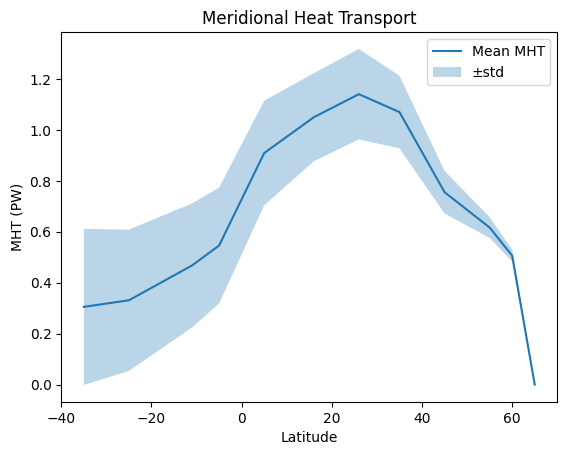

In [247]:
plt.figure()
plt.plot(lats, mht_mean, label="Mean MHT")
plt.fill_between(lats, mht_mean - mht_std, mht_mean + mht_std, alpha=0.3, label="±std")
plt.xlabel("Latitude")
plt.ylabel("MHT (PW)")
plt.title("Meridional Heat Transport")
plt.legend()
plt.show()

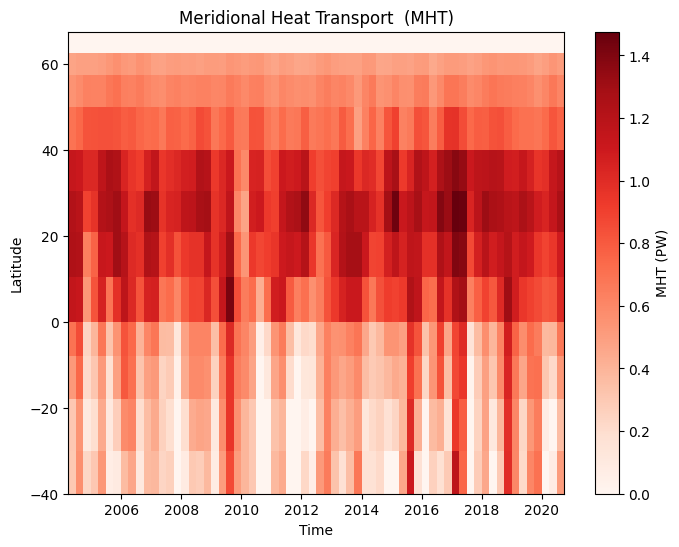

In [248]:
def plot_transport(MHT, lats, cmap="bwr", vmin=None, vmax=None):
    """
    Plot the MHT (can be anomalies or raw) as a function of time and latitude using a colormap.
    """
    plt.figure(figsize=(8, 6))

    if vmin is None and vmax is None:
        vmin = np.nanmin(MHT.values)
        vmax = np.nanmax(MHT.values)
        limit = max(abs(vmin), abs(vmax))
        vmin = -limit #- 0.5
        # vmin  = 0 
        vmax = limit #+ 0.5
    
    # plt.pcolormesh(mht_anom.TIME, lats, mht_anom.values, shading='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    plt.pcolormesh(MHT.TIME, lats, MHT.values, shading='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(label='MHT (PW)')
    plt.xlabel('Time')
    plt.ylabel('Latitude')
    # plt.title('Meridional Heat Transport Anomalies (MHT)')
    plt.title('Meridional Heat Transport  (MHT)')
    plt.show()

# cmap = cmo.cm.phase
cmap = plt.get_cmap("Reds")
# cmap = plt.get_cmap("bwr")

plot_transport(mht, lats, vmin=0, cmap=cmap)

## Correlation things

In [249]:
#cross correlation plot between latitude bands
MHT_copy = mht.rename(lat="lat2")

corr = xr.corr(mht, MHT_copy,  dim="TIME") 
print("any nan in the correlation matrix:", np.isnan(corr).any()) # True! still nans in the correlation matrix, but not in MHT itself

any nan in the correlation matrix: <xarray.DataArray 'MHT' ()> Size: 1B
array(True)


## cross correlation plot lat - lat

/var/folders/8k/45q47bzd1bxgf8pbps6hbstr0000gn/T/ipykernel_1286/603189620.py:8: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contourf(lats, lats, nan_mask, levels=[0.9, 1.1],


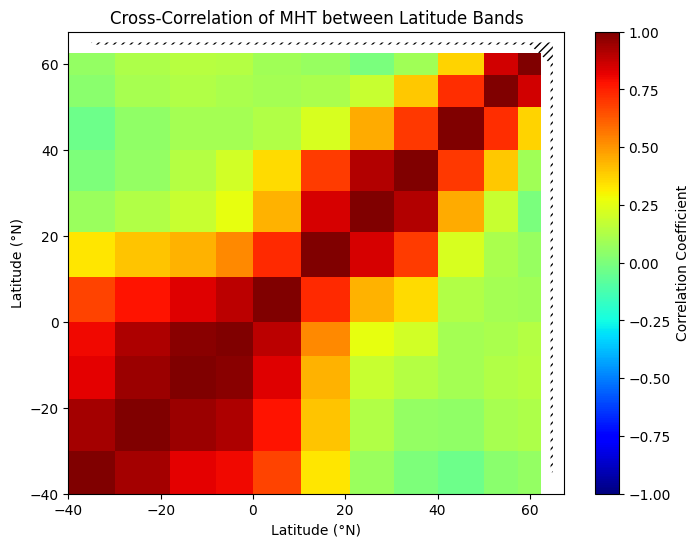

In [250]:
fig = plt.figure(figsize=(8, 6))

plt.pcolormesh(lats, lats, corr, cmap='jet', vmin=-1, vmax=1)
# origin lower put origin at bottom left, extent to set the axis limits to latitudes
plt.colorbar(label='Correlation Coefficient')

nan_mask = np.isnan(corr).astype(float)
plt.contourf(lats, lats, nan_mask, levels=[0.9, 1.1], 
             hatches=['////'], colors='none', label='NaN Mask')
# levels : to have contourf just draw the hatches where is 1 = True = there is nan

# plt.xlim(0, lats[0])
# plt.ylim(0, lats[0])

plt.xlabel('Latitude (°N)')
plt.ylabel('Latitude (°N)')
plt.title('Cross-Correlation of MHT between Latitude Bands')
plt.show()

## 0 lag correlation between 26°N and rest? 

In [251]:
mht_26

<xarray.DataArray 'MHT lat 26.0 °N' (TIME: 66)> Size: 528B
array([1.22673968, 1.1903633 , 0.89922763, 0.96643679, 1.220731  ,
       1.24711344, 1.29968575, 1.13853325, 0.97657138, 1.0099351 ,
       1.32917272, 1.31033436, 0.96289889, 1.03890466, 1.0500969 ,
       1.16620897, 1.17684916, 1.26844275, 1.28838797, 0.96467254,
       1.02385119, 1.1636328 , 0.60474267, 0.47723996, 1.07284108,
       1.10538891, 0.93525296, 0.91041985, 1.13721935, 1.22588404,
       1.25406775, 1.35458418, 1.02249739, 0.82124851, 0.91655401,
       1.01467252, 1.2148018 , 1.2637446 , 1.19074817, 1.18760001,
       1.05042934, 0.96983752, 1.28905844, 1.44810109, 1.1137018 ,
       1.17827746, 1.27488229, 1.1306596 , 1.14755584, 1.38810635,
       1.32550939, 1.47573457, 1.45873783, 1.04064921, 1.1834677 ,
       1.31392699, 1.26029947, 1.24002764, 1.19012616, 1.17244287,
       1.25590414, 1.18752229, 1.08687802, 1.03920933, 1.13996746,
       1.25993801])
Coordinates:
    LATITUDE  float64 8B 26.0
  * TIME      (TIME) datetime64[ns] 528B 2004-05-15T23:59:59.999996901 ... 20...

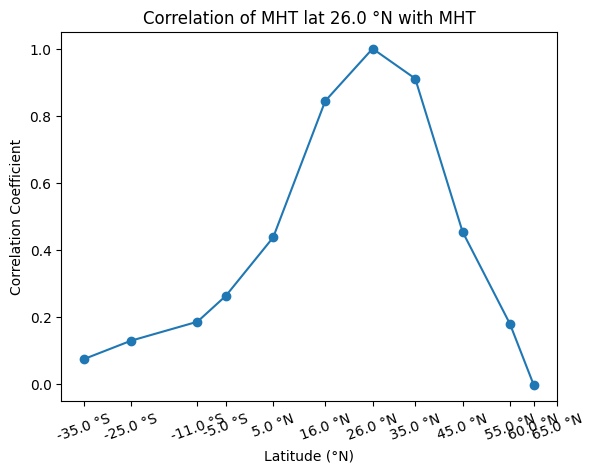

In [276]:
def zero_lag_corr(ts1, ts2, dimension="TIME", plot=False):
    """
    Compute the zero-lag Pearson correlation coefficient between two time series and plot the result as a function of latitude.
    
    """
    corr = xr.corr(ts1, ts2,  dim=dimension) 
    if plot:
        plt.figure()
        plt.plot(lats, corr, marker='o')
        plt.xticks(lats, lat_labels, rotation=20)
        plt.xlabel('Latitude (°N)')
        plt.ylabel('Correlation Coefficient')
        plt.title(f"Correlation of {ts1.name} with {ts2.name}")
        plt.show()
    
    return corr

_ = zero_lag_corr(mht_26, mht, plot=True)

In [271]:
mht_25S = MHT_selection(ds, one_band_sel=True, lat=-25)["MHT_lat"]
corr_26_25S = zero_lag_corr(mht_26, mht_25S)
print(f"Correlation between 26°N and 25°S: {corr_26_25S:.2f}")

mht_35S = MHT_selection(ds, one_band_sel=True, lat=-35)["MHT_lat"]
corr_26_35S = zero_lag_corr(mht_26, mht_35S)
print(f"Correlation between 26°N and 35°S: {corr_26_35S:.2f}")

Correlation between 26°N and 25°S: 0.13
Correlation between 26°N and 35°S: 0.08
